In [2]:
import pandas as pd
import numpy as np

# ============================================================
# Load Data
# ============================================================
df = pd.read_csv("Downloads/weekend_decisions.csv")

print("Dataset:")
print(df)
print("\n")

X = df[['Weather', 'Parents', 'Money']].values
y = df['Decision'].values
feature_names = ['Weather', 'Parents', 'Money']

Dataset:
  Weekend Weather Parents Money  Decision
0      W1   Sunny     Yes  Rich    Cinema
1      W2   Sunny      No  Rich    Tennis
2      W3   Windy     Yes  Rich    Cinema
3      W4   Rainy     Yes  Poor    Cinema
4      W5   Rainy      No  Rich   Stay In
5      W6   Rainy     Yes  Poor    Cinema
6      W7   Windy      No  Poor    Cinema
7      W8   Windy      No  Rich  Shopping
8      W9   Windy     Yes  Rich    Cinema
9     W10   Sunny      No  Rich    Tennis




In [3]:
# ============================================================
# 1. Calculate Gini Impurity
# ============================================================
def gini_impurity(y):
    """Calculate Gini Impurity for a list of labels"""
    


# ============================================================
# 2. Split Data based on a feature and value (Categorical)
# ============================================================
def split_data(X, y, feature_index, value):
    """Split data where feature == value"""
    left_mask = X[:, feature_index] == value
    right_mask = ~left_mask
    
    X_left, y_left = X[left_mask], y[left_mask]
    X_right, y_right = X[right_mask], y[right_mask]
    
    return X_left, y_left, X_right, y_right


# ============================================================
# 3. Find the Best Split using Gini Impurity
# ============================================================
def best_split(X, y, feature_names):
    """Find the best feature and value to split on"""
    best_gini = float('inf')
    best_feature = None
    best_value = None
    best_splits = None
    
    n_features = X.shape[1]
    
    for feature_index in range(n_features):
        feature_values = np.unique(X[:, feature_index])
        
        for value in feature_values:
            X_left, y_left, X_right, y_right = split_data(X, y, feature_index, value)
            
            if len(y_left) == 0 or len(y_right) == 0:
                continue
            
            # Calculate weighted Gini
            n = len(y)
            gini_left = gini_impurity(y_left)
            gini_right = gini_impurity(y_right)
            weighted_gini = (len(y_left) / n) * gini_left + (len(y_right) / n) * gini_right
            
            if weighted_gini < best_gini:
                best_gini = weighted_gini
                best_feature = feature_names[feature_index]
                best_value = value
                best_splits = (X_left, y_left, X_right, y_right)
    
    return best_feature, best_value, best_gini, best_splits


# ============================================================
# 4. Build Decision Tree Recursively
# ============================================================
def build_tree(X, y, feature_names, depth=0, max_depth=None):
    """Recursively build the decision tree"""
    
    # Stopping conditions
    if len(np.unique(y)) == 1:                    # Pure node
        return {'label': y[0]}
    
    if max_depth is not None and depth >= max_depth:
        # Return majority class
        values, counts = np.unique(y, return_counts=True)
        return {'label': values[np.argmax(counts)]}
    
    if len(y) == 0:
        return None
    
    # Find best split
    best_feature, best_value, best_gini, best_splits = best_split(X, y, feature_names)
    
    if best_feature is None:
        # No good split found → return majority class
        values, counts = np.unique(y, return_counts=True)
        return {'label': values[np.argmax(counts)]}
    
    X_left, y_left, X_right, y_right = best_splits
    
    # Recursively build left and right subtrees
    left_tree = build_tree(X_left, y_left, feature_names, depth + 1, max_depth)
    right_tree = build_tree(X_right, y_right, feature_names, depth + 1, max_depth)
    
    return {
        'feature': best_feature,
        'value': best_value,
        'gini': best_gini,
        'left': left_tree,
        'right': right_tree
    }


# ============================================================
# 5. Predict using the Tree
# ============================================================
def predict(tree, sample, feature_names):
    """Predict class for a single sample"""
    if 'label' in tree:
        return tree['label']
    
    feature_index = feature_names.index(tree['feature'])
    
    if sample[feature_index] == tree['value']:
        return predict(tree['left'], sample, feature_names)
    else:
        return predict(tree['right'], sample, feature_names)


# ============================================================
# 6. Print the Tree (for visualization)
# ============================================================
def print_tree(tree, depth=0):
    indent = "  " * depth
    if 'label' in tree:
        print(f"{indent}→ Decision: {tree['label']}")
    else:
        print(f"{indent}{tree['feature']} == {tree['value']} (Gini: {tree['gini']:.3f})")
        print_tree(tree['left'], depth + 1)
        print_tree(tree['right'], depth + 1)

In [4]:
# ============================================================
# Build and Visualize the Tree
# ============================================================
print("="*60)
print("Building Decision Tree using Gini Impurity (From Scratch)")
print("="*60)

tree = build_tree(X, y, feature_names, max_depth=3)

print("\nDecision Tree Structure:\n")
print_tree(tree)

print("\n" + "="*60)
print("Predictions on Training Data:")
print("="*60)

for i in range(len(X)):
    pred = predict(tree, X[i], feature_names)
    actual = y[i]
    status = "✓" if pred == actual else "✗"
    print(f"{df.iloc[i]['Weekend']}: Predicted = {pred}, Actual = {actual} {status}")

Building Decision Tree using Gini Impurity (From Scratch)

Decision Tree Structure:

Parents == No (Gini: 0.360)
  Weather == Sunny (Gini: 0.400)
    → Decision: Tennis
    Weather == Rainy (Gini: 0.333)
      → Decision: Stay In
      → Decision: Cinema
  → Decision: Cinema

Predictions on Training Data:
W1: Predicted = Cinema, Actual = Cinema ✓
W2: Predicted = Tennis, Actual = Tennis ✓
W3: Predicted = Cinema, Actual = Cinema ✓
W4: Predicted = Cinema, Actual = Cinema ✓
W5: Predicted = Stay In, Actual = Stay In ✓
W6: Predicted = Cinema, Actual = Cinema ✓
W7: Predicted = Cinema, Actual = Cinema ✓
W8: Predicted = Cinema, Actual = Shopping ✗
W9: Predicted = Cinema, Actual = Cinema ✓
W10: Predicted = Tennis, Actual = Tennis ✓


C:\Users\vvikr\AppData\Local\Temp\ipykernel_12880\2688532498.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


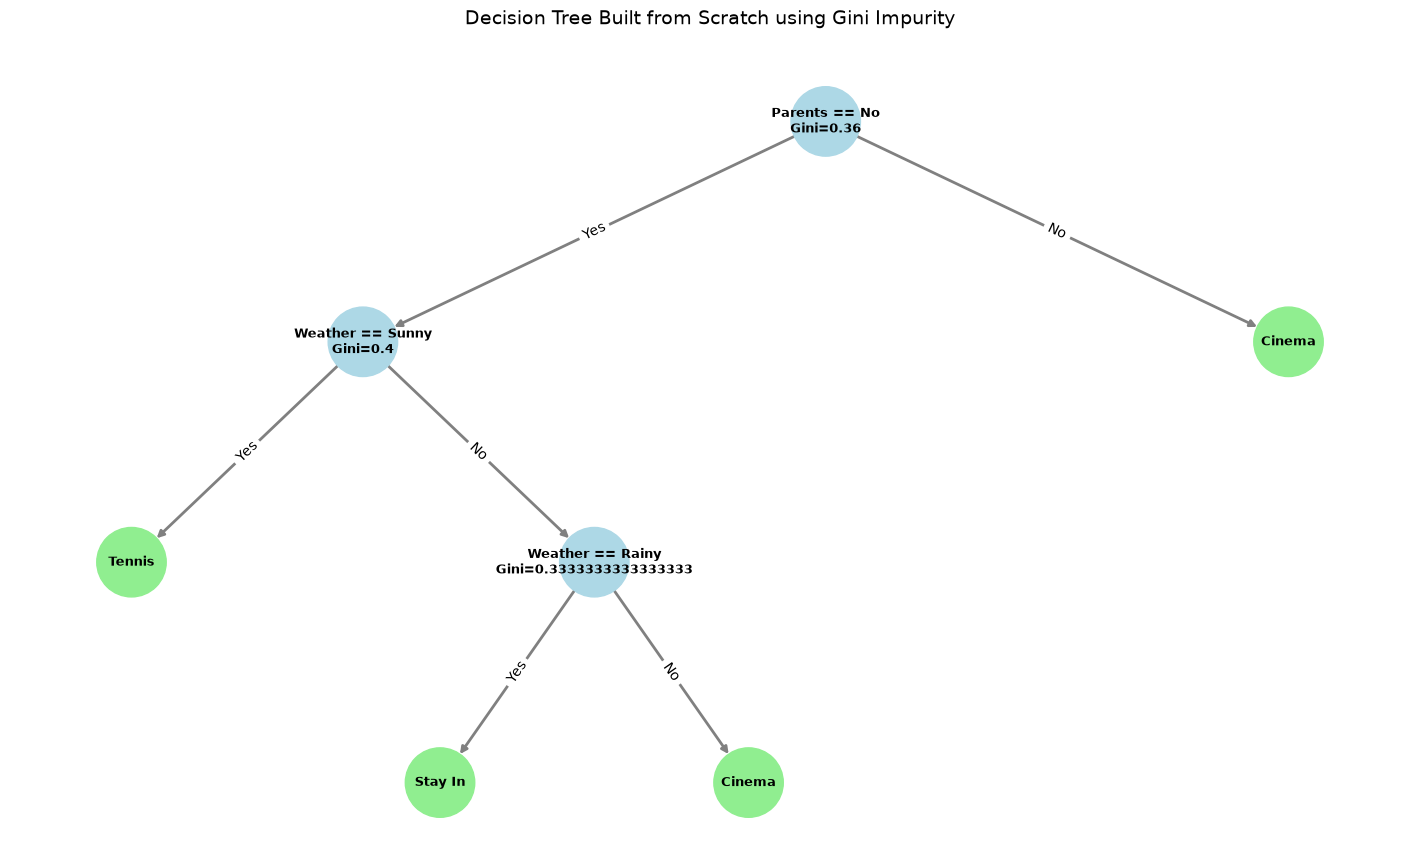

In [7]:
# ============================================================
# Visualize Tree using Matplotlib + NetworkX
# ============================================================
import networkx as nx
import matplotlib.pyplot as plt
def draw_decision_tree(tree, max_depth=3):
    G = nx.DiGraph()
    pos = {}
    labels = {}
    node_id = [0]  # mutable counter

    def add_nodes(node, depth=0, x=0):
        current_id = node_id[0]
        node_id[0] += 1
        
        if 'label' in node:
            # Leaf node
            G.add_node(current_id, label=node['label'], color='lightgreen')
            labels[current_id] = f"{node['label']}"
            pos[current_id] = (x, -depth)
            return current_id
        else:
            # Decision node
            text = f"{node['feature']} == {node['value']}\nGini={node['gini']}"
            G.add_node(current_id, label=text, color='lightblue')
            labels[current_id] = text
            pos[current_id] = (x, -depth)
            
            left_id = add_nodes(node['left'], depth+1, x - 1.5/(depth+1))
            right_id = add_nodes(node['right'], depth+1, x + 1.5/(depth+1))
            
            G.add_edge(current_id, left_id, label="Yes")
            G.add_edge(current_id, right_id, label="No")
            return current_id

    add_nodes(tree)
    
    plt.figure(figsize=(14, 8))
    colors = [G.nodes[n]['color'] for n in G.nodes]
    
    nx.draw(G, pos, with_labels=True, labels=labels, 
            node_color=colors, node_size=2500, 
            font_size=9, font_weight='bold',
            edge_color='gray', width=2)
    
    # Add edge labels (Yes/No)
    edge_labels = nx.get_edge_attributes(G, 'label')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)
    
    plt.title("Decision Tree Built from Scratch using Gini Impurity", fontsize=14, pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


# Draw the tree
draw_decision_tree(tree)